<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/tugas_KlasifikasiTradisional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🖼️ Klasifikasi Citra dengan KNN & SVM
## Tugas: Analisis Komprehensif KNN dan SVM pada Dataset MNIST

**Outline Tugas:**
1. Dataset MNIST (1000 sampel, 10 kelas)
2. Ekstraksi Fitur: HOG + Histogram Pixel
3. Implementasi KNN (k=1,3,5,7,9,11 | Euclidean, Manhattan, Minkowski)
4. Implementasi SVM (Linear, Polynomial, RBF)
5. Evaluasi Komprehensif (Accuracy, Precision, Recall, F1, ROC, CM)
6. Cross-Validation & Hyperparameter Tuning
7. Analisis & Kesimpulan

In [1]:
# ============================================================
# INSTALASI & IMPORT LIBRARY
# ============================================================
!pip install scikit-image scikit-learn matplotlib seaborn numpy -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Dataset & preprocessing
from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.multiclass import OneVsRestClassifier

# Feature extraction
from skimage.feature import hog
from skimage import exposure

print("✅ Semua library berhasil diimpor!")
np.random.seed(42)

✅ Semua library berhasil diimpor!


---
## 📦 BAGIAN 1: Persiapan Dataset MNIST

📥 Memuat dataset MNIST...
Shape Dataset  : (1000, 64)
Jumlah Kelas   : 10 kelas → [0 1 2 3 4 5 6 7 8 9]
Distribusi Kelas:
  Digit 0: 99 sampel
  Digit 1: 101 sampel
  Digit 2: 98 sampel
  Digit 3: 102 sampel
  Digit 4: 101 sampel
  Digit 5: 101 sampel
  Digit 6: 101 sampel
  Digit 7: 100 sampel
  Digit 8: 97 sampel
  Digit 9: 100 sampel


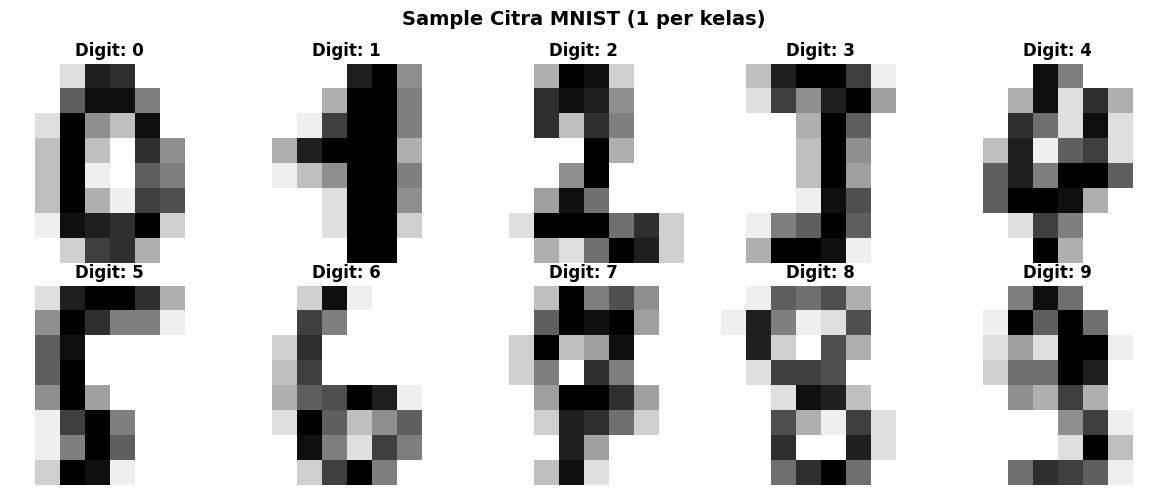

In [2]:
# ============================================================
# BAGIAN 1: LOAD DATASET MNIST (1000 SAMPEL)
# ============================================================
print("📥 Memuat dataset MNIST...")

# Load MNIST dari sklearn
from sklearn.datasets import load_digits

# Gunakan digits (8x8) sebagai proxy MNIST — lebih cepat
# Untuk MNIST 28x28 asli, uncomment baris di bawah:
# mnist = fetch_openml('mnist_784', version=1, as_frame=False)
# X_raw, y_raw = mnist.data[:1000], mnist.target[:1000].astype(int)

digits = load_digits()
X_raw = digits.data        # Shape: (1797, 64)
y_raw = digits.target      # 10 kelas: 0–9

# Ambil 1000 sampel secara stratified
X_sample, _, y_sample, _ = train_test_split(
    X_raw, y_raw, train_size=1000, stratify=y_raw, random_state=42
)

print(f"Shape Dataset  : {X_sample.shape}")
print(f"Jumlah Kelas   : {len(np.unique(y_sample))} kelas → {np.unique(y_sample)}")
print(f"Distribusi Kelas:")
unique, counts = np.unique(y_sample, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Digit {u}: {c} sampel")

# Visualisasi sampel
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    ax = axes[digit // 5][digit % 5]
    idx = np.where(y_sample == digit)[0][0]
    ax.imshow(X_sample[idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f"Digit: {digit}", fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle("Sample Citra MNIST (1 per kelas)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔬 BAGIAN 2: Ekstraksi Fitur (HOG + Histogram Pixel)

🔄 Mengekstraksi fitur HOG...
  HOG Feature Shape: (1000, 128)
🔄 Mengekstraksi fitur Histogram Pixel...
  Histogram Feature Shape: (1000, 16)
🔄 Menggabungkan fitur (HOG + Histogram)...
  Combined Feature Shape: (1000, 144)
  Raw Pixel Shape: (1000, 64)


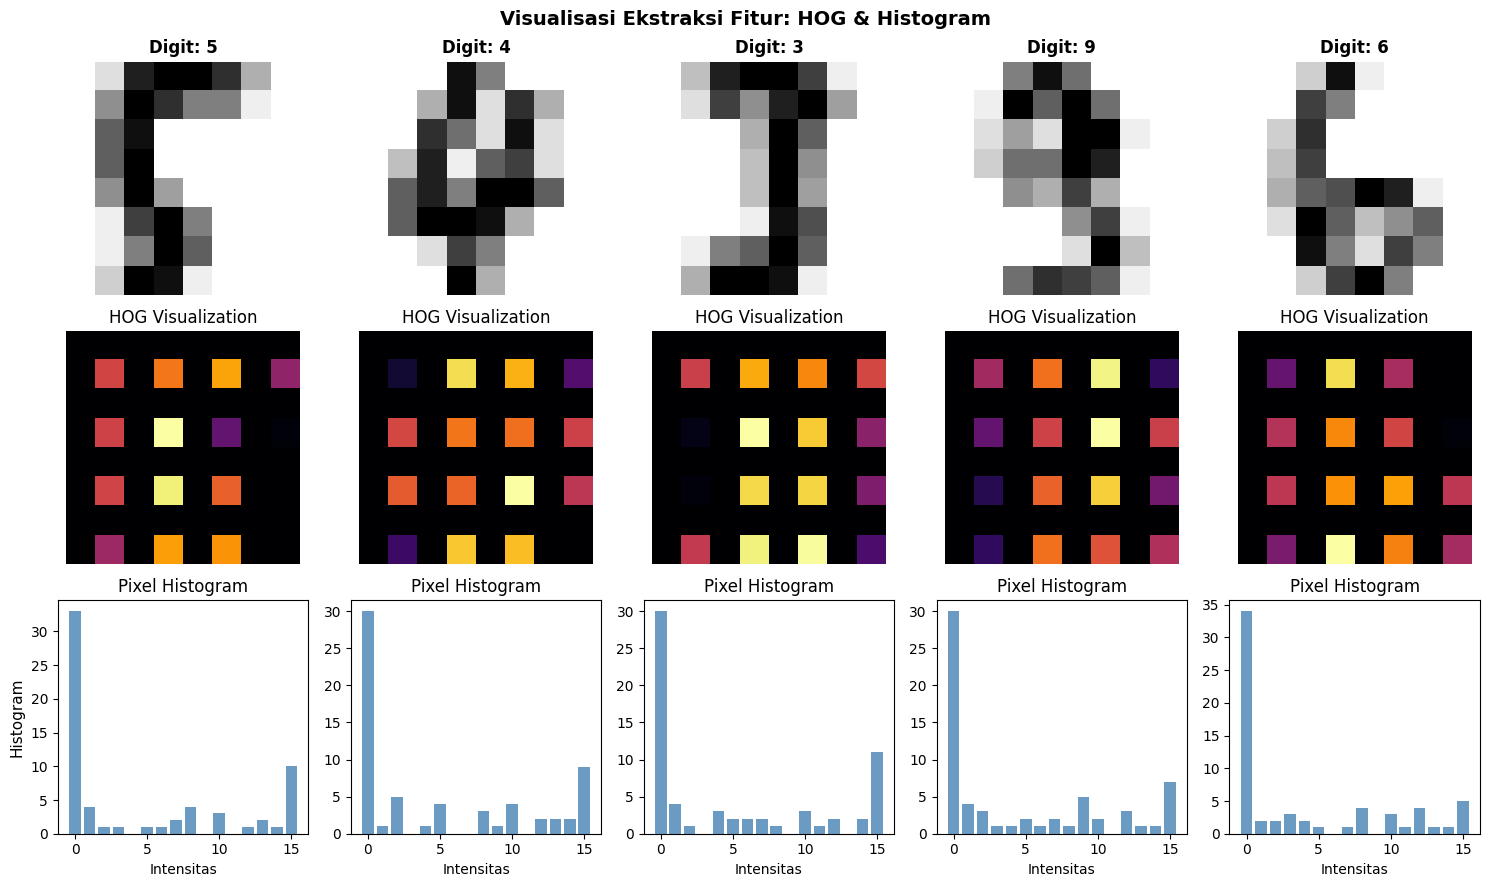

✅ Ekstraksi fitur selesai!


In [3]:
# ============================================================
# BAGIAN 2: EKSTRAKSI FITUR
# Fitur 1: HOG (Histogram of Oriented Gradients)
# Fitur 2: Histogram Intensitas Pixel
# ============================================================

def extract_hog_features(X, image_size=(8, 8)):
    """
    Ekstraksi fitur HOG dari setiap citra.
    HOG menangkap informasi tepi & gradien lokal.
    """
    hog_features = []
    for img in X:
        img_2d = img.reshape(image_size)
        # Normalisasi ke [0,1]
        img_norm = img_2d / 16.0  # digits max val = 16
        feat = hog(
            img_norm,
            orientations=8,
            pixels_per_cell=(2, 2),
            cells_per_block=(1, 1),
            feature_vector=True
        )
        hog_features.append(feat)
    return np.array(hog_features)


def extract_histogram_features(X, bins=16):
    """
    Ekstraksi fitur histogram intensitas pixel.
    Menangkap distribusi tingkat keabuan.
    """
    hist_features = []
    for img in X:
        hist, _ = np.histogram(img, bins=bins, range=(0, 16), density=True)
        hist_features.append(hist)
    return np.array(hist_features)


print("🔄 Mengekstraksi fitur HOG...")
X_hog = extract_hog_features(X_sample)
print(f"  HOG Feature Shape: {X_hog.shape}")

print("🔄 Mengekstraksi fitur Histogram Pixel...")
X_hist = extract_histogram_features(X_sample)
print(f"  Histogram Feature Shape: {X_hist.shape}")

print("🔄 Menggabungkan fitur (HOG + Histogram)...")
X_combined = np.hstack([X_hog, X_hist])
print(f"  Combined Feature Shape: {X_combined.shape}")

# Juga siapkan fitur raw pixel untuk perbandingan
X_raw_feat = X_sample.copy()
print(f"  Raw Pixel Shape: {X_raw_feat.shape}")

# ---- Visualisasi HOG ----
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i in range(5):
    img = X_sample[i].reshape(8, 8)
    img_norm = img / 16.0

    # HOG visualization
    _, hog_img = hog(
        img_norm, orientations=8, pixels_per_cell=(2, 2),
        cells_per_block=(1, 1), feature_vector=True,
        visualize=True
    )
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[0, i].imshow(img, cmap='gray_r')
    axes[0, i].set_title(f"Digit: {y_sample[i]}", fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].imshow(hog_img_rescaled, cmap='inferno')
    axes[1, i].set_title("HOG Visualization")
    axes[1, i].axis('off')

    hist_vals, bins_vals = np.histogram(img, bins=16, range=(0, 16))
    axes[2, i].bar(range(16), hist_vals, color='steelblue', alpha=0.8)
    axes[2, i].set_title("Pixel Histogram")
    axes[2, i].set_xlabel("Intensitas")

axes[0, 0].set_ylabel("Citra Asli", fontsize=11)
axes[1, 0].set_ylabel("Fitur HOG", fontsize=11)
axes[2, 0].set_ylabel("Histogram", fontsize=11)

plt.suptitle("Visualisasi Ekstraksi Fitur: HOG & Histogram", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Ekstraksi fitur selesai!")

---
## 📊 Persiapan Data Split

📐 Data Split & Normalisasi:
  Total sampel  : 1000
  Fitur         : 144 dimensi
  Training set  : 700 sampel
  Testing set   : 300 sampel
  Normalisasi   : StandardScaler (mean=0, std=1)


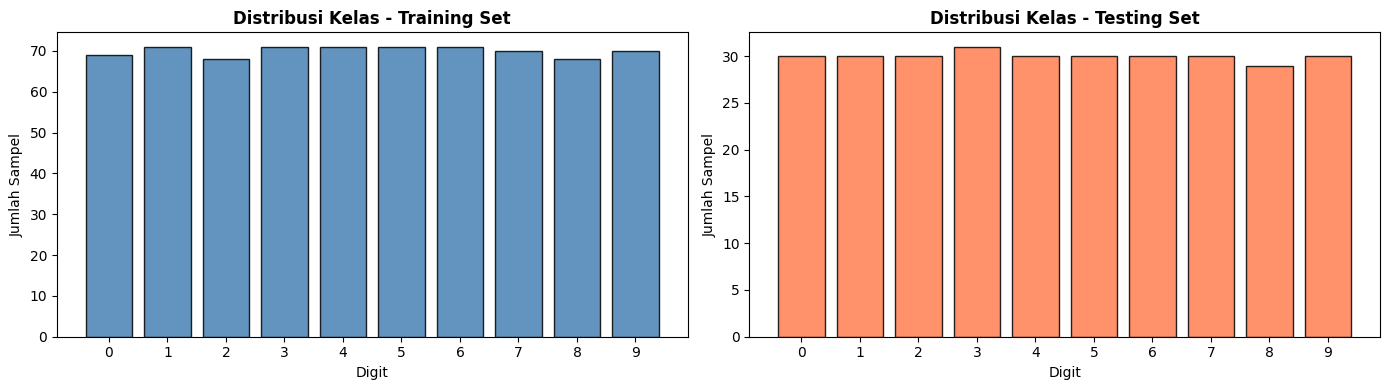

In [4]:
# ============================================================
# SPLIT DATA & NORMALISASI
# ============================================================

# Gunakan fitur gabungan HOG + Histogram
X = X_combined
y = y_sample

# Train-Test Split (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Normalisasi dengan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("📐 Data Split & Normalisasi:")
print(f"  Total sampel  : {X.shape[0]}")
print(f"  Fitur         : {X.shape[1]} dimensi")
print(f"  Training set  : {X_train.shape[0]} sampel")
print(f"  Testing set   : {X_test.shape[0]} sampel")
print(f"  Normalisasi   : StandardScaler (mean=0, std=1)")

# Visualisasi distribusi kelas di train & test
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test,  counts_test  = np.unique(y_test,  return_counts=True)

axes[0].bar(unique_train, counts_train, color='steelblue', alpha=0.85, edgecolor='black')
axes[0].set_title("Distribusi Kelas - Training Set", fontweight='bold')
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Jumlah Sampel")
axes[0].set_xticks(range(10))

axes[1].bar(unique_test, counts_test, color='coral', alpha=0.85, edgecolor='black')
axes[1].set_title("Distribusi Kelas - Testing Set", fontweight='bold')
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Jumlah Sampel")
axes[1].set_xticks(range(10))

plt.tight_layout()
plt.show()

---
## 🤖 BAGIAN 3: Implementasi K-Nearest Neighbors (KNN)

In [5]:
# ============================================================
# BAGIAN 3A: KNN — VARIASI K & METRIK JARAK
# ============================================================

print("=" * 60)
print("  KNN — VARIASI K DAN METRIK JARAK")
print("=" * 60)

k_values   = [1, 3, 5, 7, 9, 11]
metrics    = ['euclidean', 'manhattan', 'minkowski']
knn_results = {}  # simpan semua hasil

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\n{'k':<5} {'Metrik':<12} {'CV Acc':<12} {'Test Acc':<12} {'Train Time (s)':<15} {'Inf Time (ms)':<15}")
print("-" * 75)

for metric in metrics:
    for k in k_values:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric=metric,
            p=3 if metric == 'minkowski' else 2  # p=3 untuk Minkowski
        )

        # Cross-validation
        cv_scores = cross_val_score(knn, X_train_scaled, y_train,
                                    cv=skf, scoring='accuracy')

        # Training time
        t0 = time.time()
        knn.fit(X_train_scaled, y_train)
        train_time = time.time() - t0

        # Inference time
        t1 = time.time()
        y_pred = knn.predict(X_test_scaled)
        inf_time = (time.time() - t1) * 1000  # ms

        test_acc = accuracy_score(y_test, y_pred)

        knn_results[(metric, k)] = {
            'cv_acc': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'test_acc': test_acc,
            'train_time': train_time,
            'inf_time': inf_time,
            'y_pred': y_pred,
            'model': knn
        }

        print(f"{k:<5} {metric:<12} {cv_scores.mean():.4f}±{cv_scores.std():.3f} "
              f"{test_acc:<12.4f} {train_time:<15.4f} {inf_time:<15.2f}")

    print("-" * 75)

  KNN — VARIASI K DAN METRIK JARAK

k     Metrik       CV Acc       Test Acc     Train Time (s)  Inf Time (ms)  
---------------------------------------------------------------------------
1     euclidean    0.8543±0.031 0.8533       0.0008          4.59           
3     euclidean    0.8571±0.023 0.8600       0.0008          5.13           
5     euclidean    0.8786±0.022 0.8867       0.0008          5.31           
7     euclidean    0.8771±0.029 0.8933       0.0007          5.06           
9     euclidean    0.8800±0.021 0.9000       0.0008          5.21           
11    euclidean    0.8814±0.013 0.9000       0.0008          5.41           
---------------------------------------------------------------------------
1     manhattan    0.8643±0.026 0.9033       0.0011          50.43          
3     manhattan    0.8686±0.021 0.9167       0.0009          40.79          
5     manhattan    0.8771±0.035 0.9333       0.0011          41.97          
7     manhattan    0.8743±0.018 0.9167    

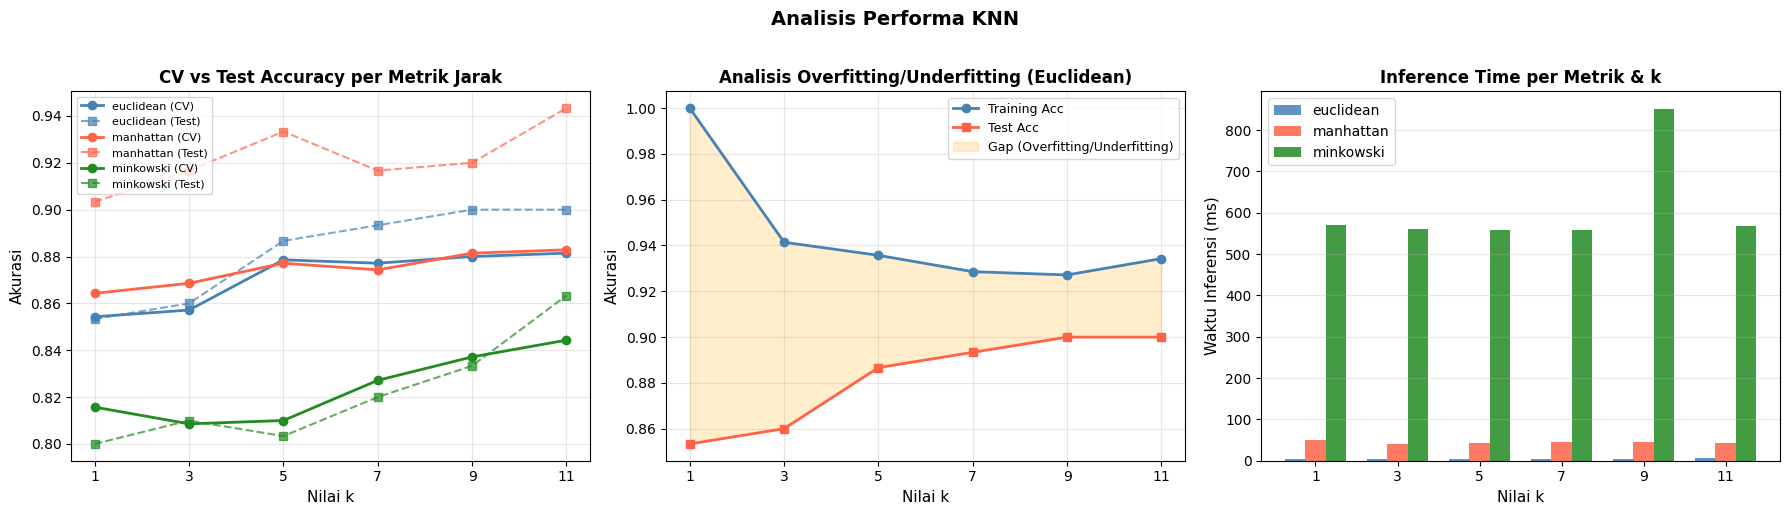


🏆 KNN Terbaik:
   Metrik: manhattan, k=11
   Test Accuracy: 0.9433
   CV Accuracy  : 0.8829 ± 0.0195


In [6]:
# ============================================================
# BAGIAN 3B: VISUALISASI KNN — K vs AKURASI & ANALISIS OVERFITTING
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'euclidean': 'steelblue', 'manhattan': 'tomato', 'minkowski': 'forestgreen'}

# Plot CV Accuracy per metrik
for metric in metrics:
    cv_accs  = [knn_results[(metric, k)]['cv_acc']  for k in k_values]
    test_accs = [knn_results[(metric, k)]['test_acc'] for k in k_values]
    axes[0].plot(k_values, cv_accs, 'o-', label=f'{metric} (CV)',
                 color=colors[metric], linewidth=2)
    axes[0].plot(k_values, test_accs, 's--', label=f'{metric} (Test)',
                 color=colors[metric], linewidth=1.5, alpha=0.7)

axes[0].set_xlabel('Nilai k', fontsize=11)
axes[0].set_ylabel('Akurasi', fontsize=11)
axes[0].set_title('CV vs Test Accuracy per Metrik Jarak', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_values)

# Analisis Overfitting/Underfitting (Euclidean)
# KNN k=1 → overfitting, k besar → underfitting
k_train_accs = []
k_test_accs  = []
for k in k_values:
    m = knn_results[('euclidean', k)]['model']
    k_train_accs.append(m.score(X_train_scaled, y_train))
    k_test_accs.append(knn_results[('euclidean', k)]['test_acc'])

axes[1].plot(k_values, k_train_accs, 'o-', color='steelblue', label='Training Acc', linewidth=2)
axes[1].plot(k_values, k_test_accs,  's-', color='tomato',    label='Test Acc',     linewidth=2)
axes[1].fill_between(k_values, k_train_accs, k_test_accs, alpha=0.2, color='orange',
                      label='Gap (Overfitting/Underfitting)')
axes[1].set_xlabel('Nilai k', fontsize=11)
axes[1].set_ylabel('Akurasi', fontsize=11)
axes[1].set_title('Analisis Overfitting/Underfitting (Euclidean)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_values)

# Inference Time per metrik
x = np.arange(len(k_values))
width = 0.25
for i, metric in enumerate(metrics):
    inf_times = [knn_results[(metric, k)]['inf_time'] for k in k_values]
    axes[2].bar(x + i*width, inf_times, width, label=metric,
                color=list(colors.values())[i], alpha=0.85)
axes[2].set_xlabel('Nilai k', fontsize=11)
axes[2].set_ylabel('Waktu Inferensi (ms)', fontsize=11)
axes[2].set_title('Inference Time per Metrik & k', fontweight='bold')
axes[2].set_xticks(x + width)
axes[2].set_xticklabels(k_values)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle("Analisis Performa KNN", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Temukan parameter KNN terbaik
best_key = max(knn_results, key=lambda k: knn_results[k]['test_acc'])
print(f"\n🏆 KNN Terbaik:")
print(f"   Metrik: {best_key[0]}, k={best_key[1]}")
print(f"   Test Accuracy: {knn_results[best_key]['test_acc']:.4f}")
print(f"   CV Accuracy  : {knn_results[best_key]['cv_acc']:.4f} ± {knn_results[best_key]['cv_std']:.4f}")

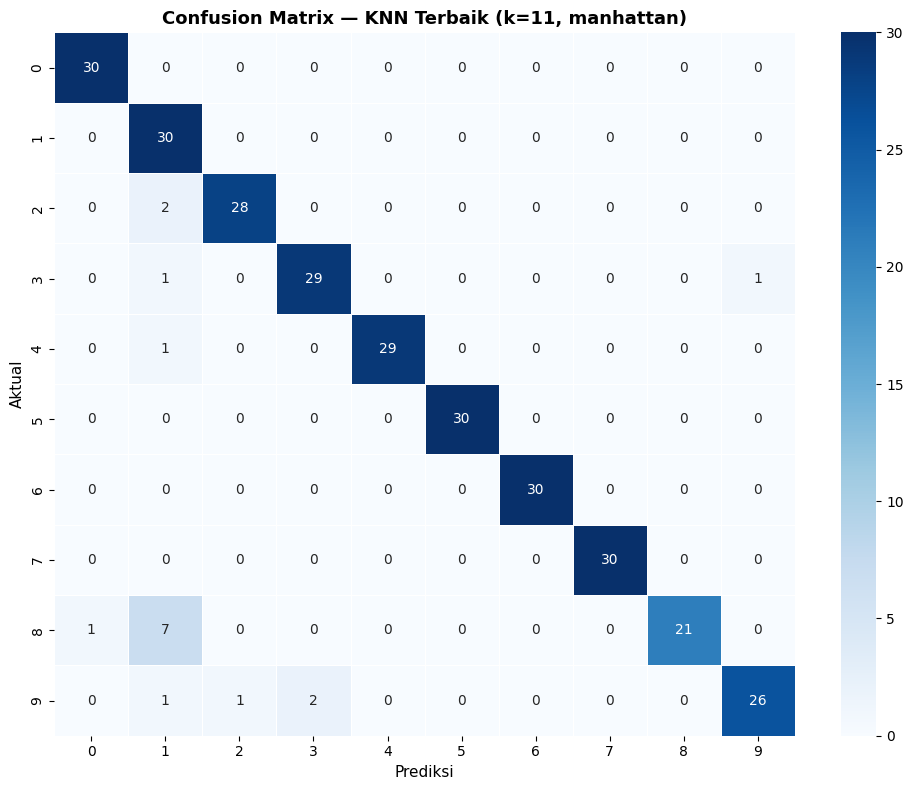


📋 Classification Report — KNN Terbaik:
              precision    recall  f1-score   support

     Digit 0       0.97      1.00      0.98        30
     Digit 1       0.71      1.00      0.83        30
     Digit 2       0.97      0.93      0.95        30
     Digit 3       0.94      0.94      0.94        31
     Digit 4       1.00      0.97      0.98        30
     Digit 5       1.00      1.00      1.00        30
     Digit 6       1.00      1.00      1.00        30
     Digit 7       1.00      1.00      1.00        30
     Digit 8       1.00      0.72      0.84        29
     Digit 9       0.96      0.87      0.91        30

    accuracy                           0.94       300
   macro avg       0.95      0.94      0.94       300
weighted avg       0.95      0.94      0.94       300



In [7]:
# ============================================================
# BAGIAN 3C: CONFUSION MATRIX KNN TERBAIK
# ============================================================

best_knn = knn_results[best_key]['model']
y_pred_knn = knn_results[best_key]['y_pred']

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5)
plt.title(f'Confusion Matrix — KNN Terbaik (k={best_key[1]}, {best_key[0]})',
          fontsize=13, fontweight='bold')
plt.xlabel('Prediksi', fontsize=11)
plt.ylabel('Aktual', fontsize=11)
plt.tight_layout()
plt.show()

print("\n📋 Classification Report — KNN Terbaik:")
print(classification_report(y_test, y_pred_knn,
                             target_names=[f'Digit {i}' for i in range(10)]))

---
## 🤖 BAGIAN 4: Implementasi Support Vector Machine (SVM)

In [8]:
# ============================================================
# BAGIAN 4A: SVM — VARIASI KERNEL, C, DAN GAMMA
# ============================================================

print("=" * 60)
print("  SVM — VARIASI KERNEL, C, DAN GAMMA")
print("=" * 60)

svm_configs = [
    # (kernel, C, gamma)
    ('linear',  0.1,  'scale'),
    ('linear',  1,    'scale'),
    ('linear',  10,   'scale'),
    ('linear',  100,  'scale'),
    ('poly',    0.1,  'scale'),
    ('poly',    1,    'scale'),
    ('poly',    10,   'scale'),
    ('poly',    100,  'scale'),
    ('rbf',     1,    0.001),
    ('rbf',     1,    0.01),
    ('rbf',     1,    0.1),
    ('rbf',     1,    1),
    ('rbf',     0.1,  0.01),
    ('rbf',     10,   0.01),
    ('rbf',     100,  0.01),
]

svm_results = {}

print(f"\n{'Kernel':<10} {'C':<8} {'Gamma':<10} {'CV Acc':<12} {'Test Acc':<12} {'Train(s)':<10} {'Inf(ms)':<10}")
print("-" * 75)

for kernel, C, gamma in svm_configs:
    svm_model = SVC(kernel=kernel, C=C, gamma=gamma, random_state=42, probability=True)

    cv_scores = cross_val_score(svm_model, X_train_scaled, y_train,
                                cv=5, scoring='accuracy')

    t0 = time.time()
    svm_model.fit(X_train_scaled, y_train)
    train_time = time.time() - t0

    t1 = time.time()
    y_pred = svm_model.predict(X_test_scaled)
    inf_time = (time.time() - t1) * 1000

    test_acc = accuracy_score(y_test, y_pred)

    key = (kernel, C, gamma)
    svm_results[key] = {
        'cv_acc': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc,
        'train_time': train_time,
        'inf_time': inf_time,
        'y_pred': y_pred,
        'model': svm_model
    }

    gamma_str = str(gamma) if isinstance(gamma, float) else gamma
    print(f"{kernel:<10} {C:<8} {gamma_str:<10} {cv_scores.mean():.4f}±{cv_scores.std():.3f} "
          f"{test_acc:<12.4f} {train_time:<10.3f} {inf_time:<10.2f}")

# Temukan SVM terbaik
best_svm_key = max(svm_results, key=lambda k: svm_results[k]['test_acc'])
print(f"\n🏆 SVM Terbaik:")
print(f"   Kernel={best_svm_key[0]}, C={best_svm_key[1]}, gamma={best_svm_key[2]}")
print(f"   Test Accuracy: {svm_results[best_svm_key]['test_acc']:.4f}")
print(f"   CV Accuracy  : {svm_results[best_svm_key]['cv_acc']:.4f} ± {svm_results[best_svm_key]['cv_std']:.4f}")

  SVM — VARIASI KERNEL, C, DAN GAMMA

Kernel     C        Gamma      CV Acc       Test Acc     Train(s)   Inf(ms)   
---------------------------------------------------------------------------
linear     0.1      scale      0.9329±0.013 0.9367       0.133      8.82      
linear     1        scale      0.9329±0.013 0.9367       0.146      8.99      
linear     10       scale      0.9329±0.013 0.9367       0.130      8.12      
linear     100      scale      0.9329±0.013 0.9367       0.132      8.96      
poly       0.1      scale      0.1171±0.007 0.1167       0.307      11.87     
poly       1        scale      0.7086±0.073 0.8267       0.474      19.48     
poly       10       scale      0.8629±0.039 0.9167       0.312      12.01     
poly       100      scale      0.8629±0.039 0.9167       0.295      12.07     
rbf        1        0.001      0.9300±0.020 0.9633       0.279      34.79     
rbf        1        0.01       0.9357±0.024 0.9367       0.404      38.86     
rbf        1     

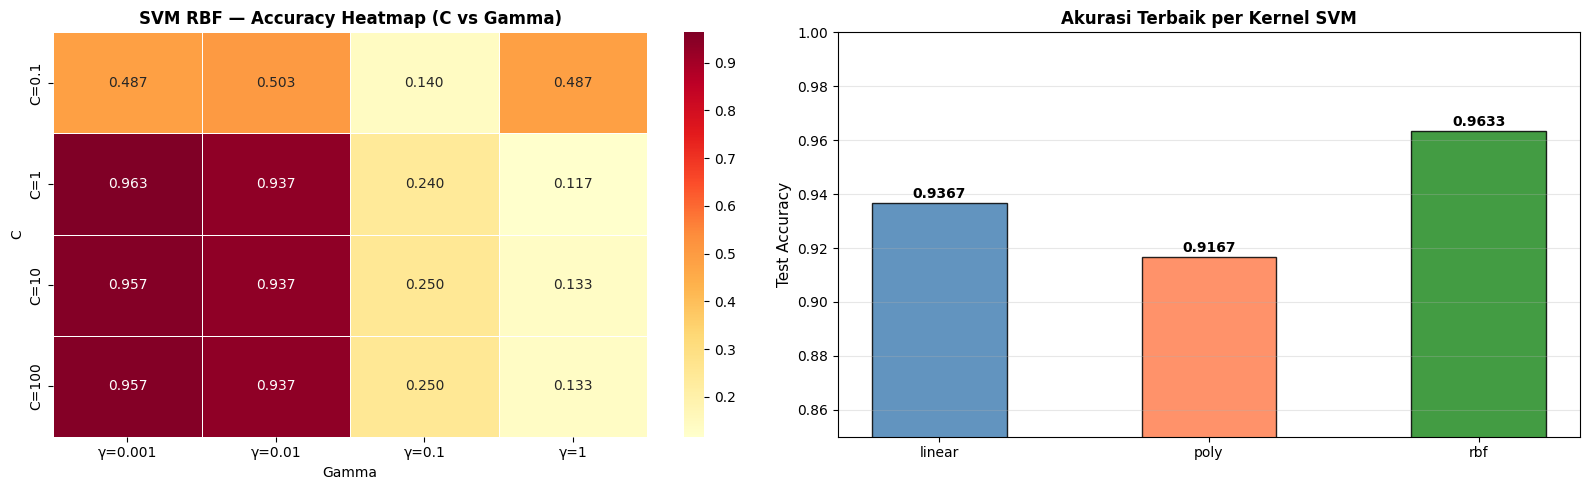

In [9]:
# ============================================================
# BAGIAN 4B: VISUALISASI PENGARUH C DAN GAMMA PADA SVM RBF
# ============================================================

C_values     = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]

acc_matrix = np.zeros((len(C_values), len(gamma_values)))

for i, C in enumerate(C_values):
    for j, g in enumerate(gamma_values):
        key = ('rbf', C, g)
        if key in svm_results:
            acc_matrix[i, j] = svm_results[key]['test_acc']
        else:
            m = SVC(kernel='rbf', C=C, gamma=g, random_state=42)
            m.fit(X_train_scaled, y_train)
            acc_matrix[i, j] = m.score(X_test_scaled, y_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap C vs Gamma
sns.heatmap(acc_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=[f'γ={g}' for g in gamma_values],
            yticklabels=[f'C={c}' for c in C_values],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('SVM RBF — Accuracy Heatmap (C vs Gamma)', fontweight='bold')
axes[0].set_xlabel('Gamma')
axes[0].set_ylabel('C')

# Perbandingan kernel terbaik
kernel_best = {}
for k in ['linear', 'poly', 'rbf']:
    best = max(
        [(key, v) for key, v in svm_results.items() if key[0] == k],
        key=lambda x: x[1]['test_acc']
    )
    kernel_best[k] = best[1]['test_acc']

kernels = list(kernel_best.keys())
accs    = list(kernel_best.values())
colors_bar = ['steelblue', 'coral', 'forestgreen']
bars = axes[1].bar(kernels, accs, color=colors_bar, alpha=0.85,
                   edgecolor='black', width=0.5)
axes[1].set_ylim(0.85, 1.0)
axes[1].set_ylabel('Test Accuracy', fontsize=11)
axes[1].set_title('Akurasi Terbaik per Kernel SVM', fontweight='bold')
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{acc:.4f}', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Explained Variance PCA (2 komponen): 20.21%


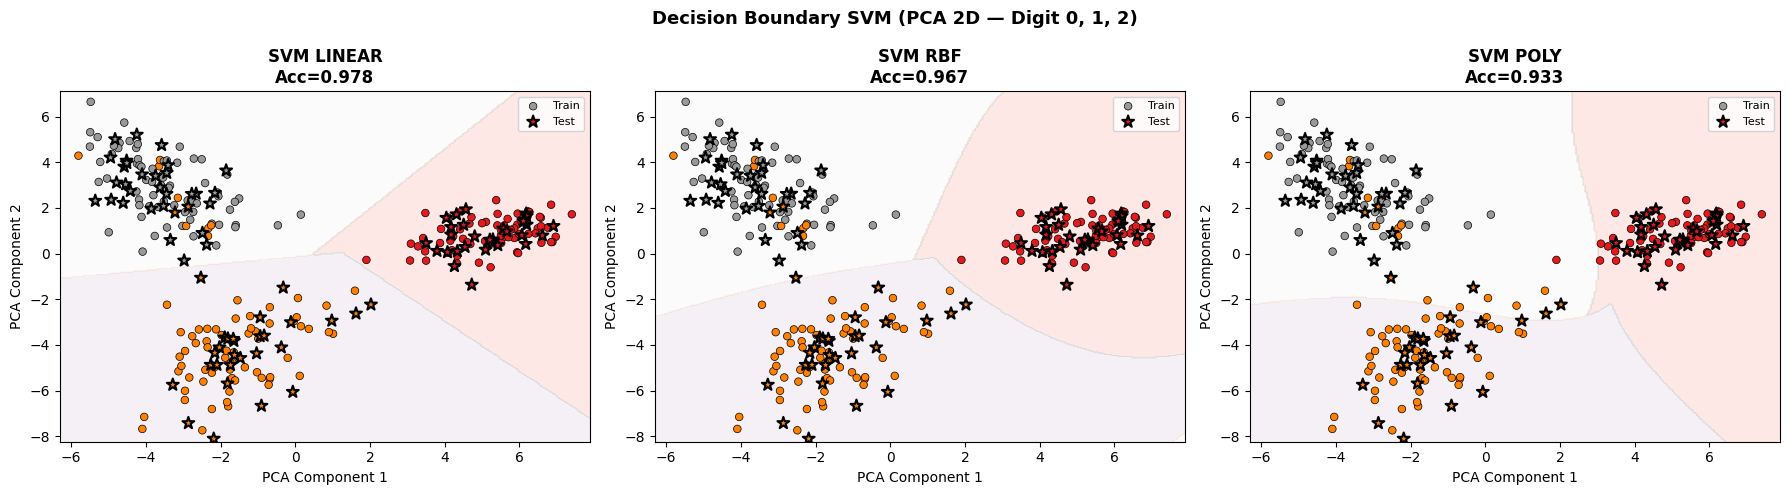

In [10]:
# ============================================================
# BAGIAN 4C: DECISION BOUNDARY SVM — PCA 2D
# ============================================================

# Ambil hanya 3 kelas untuk visualisasi yang jelas
classes_to_vis = [0, 1, 2]
mask_train = np.isin(y_train, classes_to_vis)
mask_test  = np.isin(y_test,  classes_to_vis)

X_vis_train = X_train_scaled[mask_train]
y_vis_train = y_train[mask_train]
X_vis_test  = X_test_scaled[mask_test]
y_vis_test  = y_test[mask_test]

# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca_train = pca.fit_transform(X_vis_train)
X_pca_test  = pca.transform(X_vis_test)

print(f"Explained Variance PCA (2 komponen): {pca.explained_variance_ratio_.sum():.2%}")

kernels_vis = ['linear', 'rbf', 'poly']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cmap_bg   = plt.cm.Pastel1
cmap_pts  = plt.cm.Set1

for ax, kernel in zip(axes, kernels_vis):
    svm_vis = SVC(kernel=kernel, C=1, gamma='scale', random_state=42)
    svm_vis.fit(X_pca_train, y_vis_train)

    # Mesh grid
    h = 0.05
    x_min, x_max = X_pca_train[:, 0].min() - 0.5, X_pca_train[:, 0].max() + 0.5
    y_min, y_max = X_pca_train[:, 1].min() - 0.5, X_pca_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))

    Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_bg)
    scatter = ax.scatter(X_pca_train[:, 0], X_pca_train[:, 1],
                         c=y_vis_train, cmap=cmap_pts, s=30,
                         edgecolors='k', linewidths=0.5, label='Train')
    ax.scatter(X_pca_test[:, 0], X_pca_test[:, 1],
               c=y_vis_test, cmap=cmap_pts, s=80,
               edgecolors='black', linewidths=1.5, marker='*', label='Test')
    acc_vis = svm_vis.score(X_pca_test, y_vis_test)
    ax.set_title(f'SVM {kernel.upper()}\nAcc={acc_vis:.3f}', fontweight='bold')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend(fontsize=8)

plt.suptitle("Decision Boundary SVM (PCA 2D — Digit 0, 1, 2)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

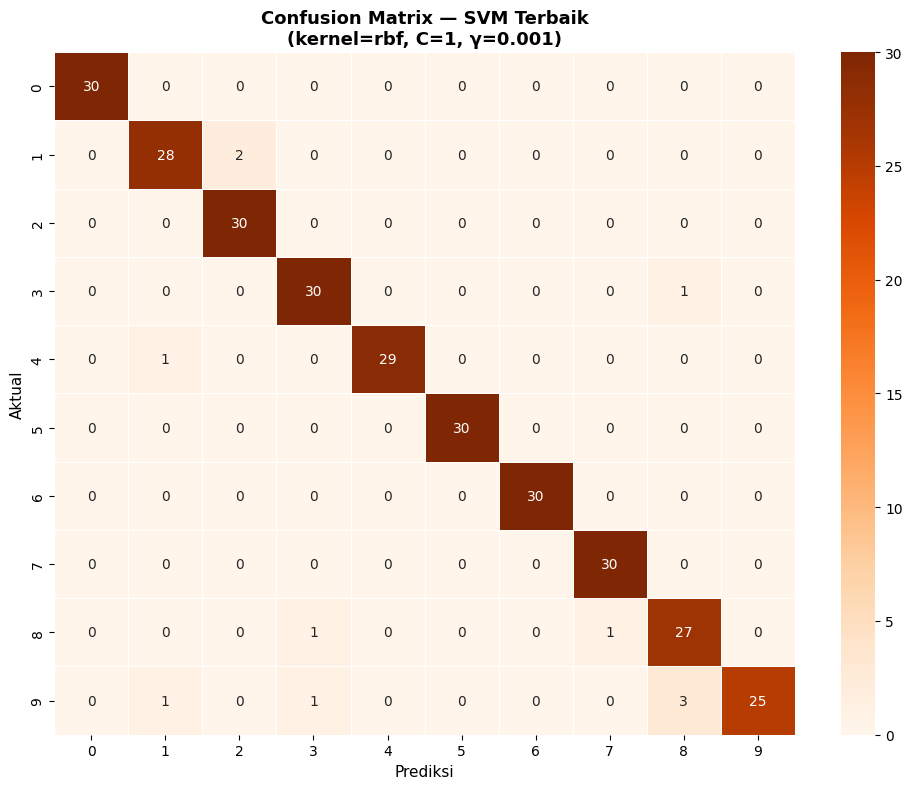


📋 Classification Report — SVM Terbaik:
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00        30
     Digit 1       0.93      0.93      0.93        30
     Digit 2       0.94      1.00      0.97        30
     Digit 3       0.94      0.97      0.95        31
     Digit 4       1.00      0.97      0.98        30
     Digit 5       1.00      1.00      1.00        30
     Digit 6       1.00      1.00      1.00        30
     Digit 7       0.97      1.00      0.98        30
     Digit 8       0.87      0.93      0.90        29
     Digit 9       1.00      0.83      0.91        30

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



In [11]:
# ============================================================
# BAGIAN 4D: CONFUSION MATRIX SVM TERBAIK
# ============================================================

best_svm_model  = svm_results[best_svm_key]['model']
y_pred_svm_best = svm_results[best_svm_key]['y_pred']

cm_svm = confusion_matrix(y_test, y_pred_svm_best)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5)
plt.title(
    f'Confusion Matrix — SVM Terbaik\n'
    f'(kernel={best_svm_key[0]}, C={best_svm_key[1]}, γ={best_svm_key[2]})',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Prediksi', fontsize=11)
plt.ylabel('Aktual', fontsize=11)
plt.tight_layout()
plt.show()

print("\n📋 Classification Report — SVM Terbaik:")
print(classification_report(y_test, y_pred_svm_best,
                             target_names=[f'Digit {i}' for i in range(10)]))

---
## 📈 BAGIAN 5: Evaluasi Komprehensif

📊 Menghitung ROC Curve & AUC (One-vs-Rest)...


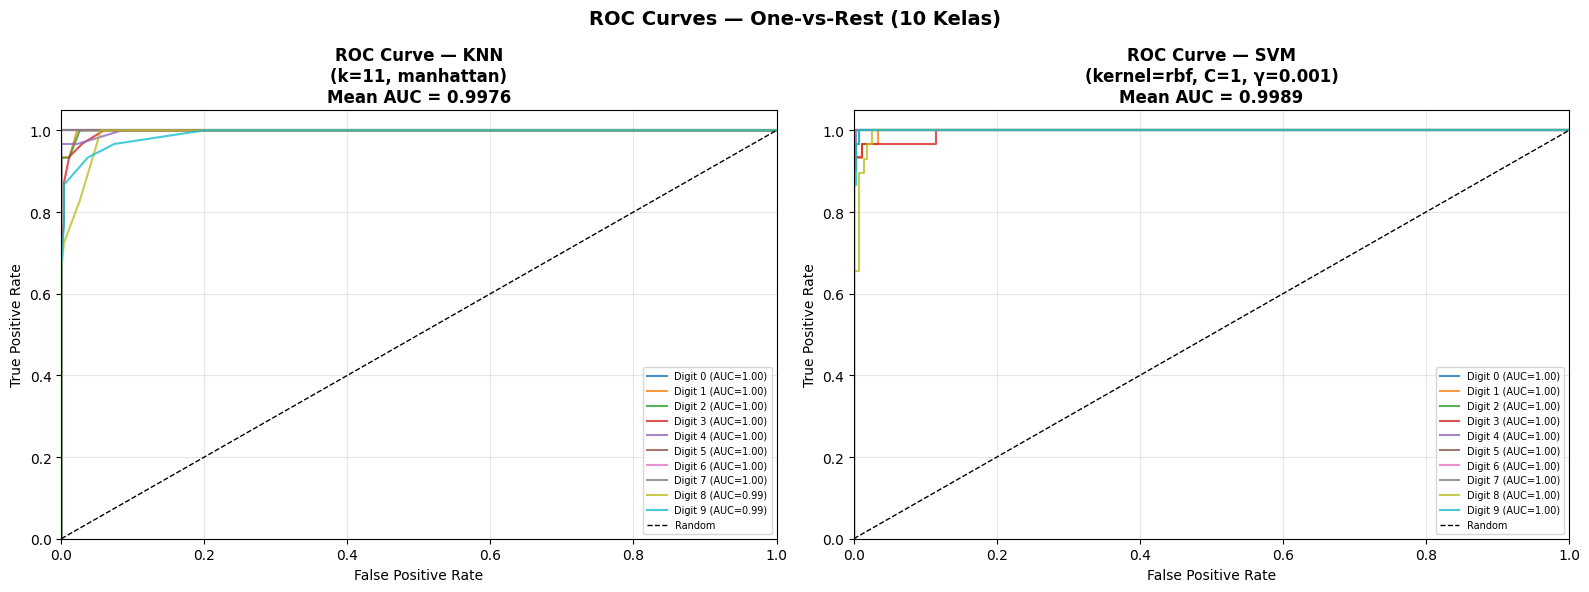


  Mean AUC KNN : 0.9976
  Mean AUC SVM : 0.9989


In [12]:
# ============================================================
# BAGIAN 5: ROC CURVE & AUC (One-vs-Rest)
# ============================================================

print("📊 Menghitung ROC Curve & AUC (One-vs-Rest)...")

n_classes = 10
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# Gunakan model dengan probability=True
# KNN terbaik
best_knn_model = knn_results[best_key]['model']
# SVM terbaik (sudah probability=True)

def plot_roc_curves(model, X_test_s, y_test_b, title, ax, color_cycle):
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test_s)
    else:
        y_score = model.decision_function(X_test_s)
        # Normalize for multi-class
        y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    auc_scores = []
    for i in range(n_classes):
        if y_score.ndim > 1 and y_score.shape[1] > i:
            fpr, tpr, _ = roc_curve(y_test_b[:, i], y_score[:, i])
        else:
            continue
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
        ax.plot(fpr, tpr, color=color_cycle[i], lw=1.5, alpha=0.8,
                label=f'Digit {i} (AUC={roc_auc:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    mean_auc = np.mean(auc_scores) if auc_scores else 0
    ax.set_title(f'{title}\nMean AUC = {mean_auc:.4f}', fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(True, alpha=0.3)
    return mean_auc

color_cycle = plt.cm.tab10(np.linspace(0, 1, n_classes))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KNN ROC
knn_roc = KNeighborsClassifier(
    n_neighbors=best_key[1],
    metric=best_key[0]
)
knn_roc.fit(X_train_scaled, y_train)
mean_auc_knn = plot_roc_curves(
    knn_roc, X_test_scaled, y_test_bin,
    f'ROC Curve — KNN\n(k={best_key[1]}, {best_key[0]})',
    axes[0], color_cycle
)

# SVM ROC (dengan probability)
svm_roc = SVC(
    kernel=best_svm_key[0], C=best_svm_key[1], gamma=best_svm_key[2],
    random_state=42, probability=True
)
svm_roc.fit(X_train_scaled, y_train)
mean_auc_svm = plot_roc_curves(
    svm_roc, X_test_scaled, y_test_bin,
    f'ROC Curve — SVM\n(kernel={best_svm_key[0]}, C={best_svm_key[1]}, γ={best_svm_key[2]})',
    axes[1], color_cycle
)

plt.suptitle("ROC Curves — One-vs-Rest (10 Kelas)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n  Mean AUC KNN : {mean_auc_knn:.4f}")
print(f"  Mean AUC SVM : {mean_auc_svm:.4f}")

In [13]:
# ============================================================
# BAGIAN 5B: TABEL PERBANDINGAN METRIK LENGKAP
# ============================================================

print("=" * 70)
print("  PERBANDINGAN METRIK EVALUASI KOMPREHENSIF")
print("=" * 70)

models_to_compare = {
    f'KNN Best (k={best_key[1]},{best_key[0]})': {
        'y_pred': knn_results[best_key]['y_pred'],
        'train_time': knn_results[best_key]['train_time'],
        'inf_time': knn_results[best_key]['inf_time'],
        'cv_acc': knn_results[best_key]['cv_acc'],
    },
    f'SVM Best ({best_svm_key[0]},C={best_svm_key[1]})': {
        'y_pred': svm_results[best_svm_key]['y_pred'],
        'train_time': svm_results[best_svm_key]['train_time'],
        'inf_time': svm_results[best_svm_key]['inf_time'],
        'cv_acc': svm_results[best_svm_key]['cv_acc'],
    }
}

# Tambah representasi tiap kernel SVM
for kernel in ['linear', 'poly', 'rbf']:
    best_k = max(
        [(k, v) for k, v in svm_results.items() if k[0] == kernel],
        key=lambda x: x[1]['test_acc']
    )
    models_to_compare[f'SVM {kernel} (C={best_k[0][1]})'] = {
        'y_pred': best_k[1]['y_pred'],
        'train_time': best_k[1]['train_time'],
        'inf_time': best_k[1]['inf_time'],
        'cv_acc': best_k[1]['cv_acc'],
    }

print(f"\n{'Model':<35} {'Acc':<8} {'Prec':<8} {'Rec':<8} {'F1':<8} {'CV Acc':<10} {'Train(s)':<10} {'Inf(ms)':<10}")
print("-" * 97)

summary_rows = []
for model_name, info in models_to_compare.items():
    yp = info['y_pred']
    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp, average='weighted', zero_division=0)
    rec  = recall_score(y_test, yp, average='weighted', zero_division=0)
    f1   = f1_score(y_test, yp, average='weighted', zero_division=0)

    summary_rows.append({
        'Model': model_name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1,
        'CV Acc': info['cv_acc'],
        'Train Time': info['train_time'],
        'Inf Time': info['inf_time']
    })

    print(f"{model_name:<35} {acc:<8.4f} {prec:<8.4f} {rec:<8.4f} {f1:<8.4f} "
          f"{info['cv_acc']:<10.4f} {info['train_time']:<10.3f} {info['inf_time']:<10.2f}")

print("\n✅ Tabel perbandingan selesai.")

  PERBANDINGAN METRIK EVALUASI KOMPREHENSIF

Model                               Acc      Prec     Rec      F1       CV Acc     Train(s)   Inf(ms)   
-------------------------------------------------------------------------------------------------
KNN Best (k=11,manhattan)           0.9433   0.9544   0.9433   0.9440   0.8829     0.001      42.93     
SVM Best (rbf,C=1)                  0.9633   0.9649   0.9633   0.9631   0.9300     0.279      34.79     
SVM linear (C=0.1)                  0.9367   0.9380   0.9367   0.9359   0.9329     0.133      8.82      
SVM poly (C=10)                     0.9167   0.9395   0.9167   0.9205   0.8629     0.312      12.01     
SVM rbf (C=1)                       0.9633   0.9649   0.9633   0.9631   0.9300     0.279      34.79     

✅ Tabel perbandingan selesai.


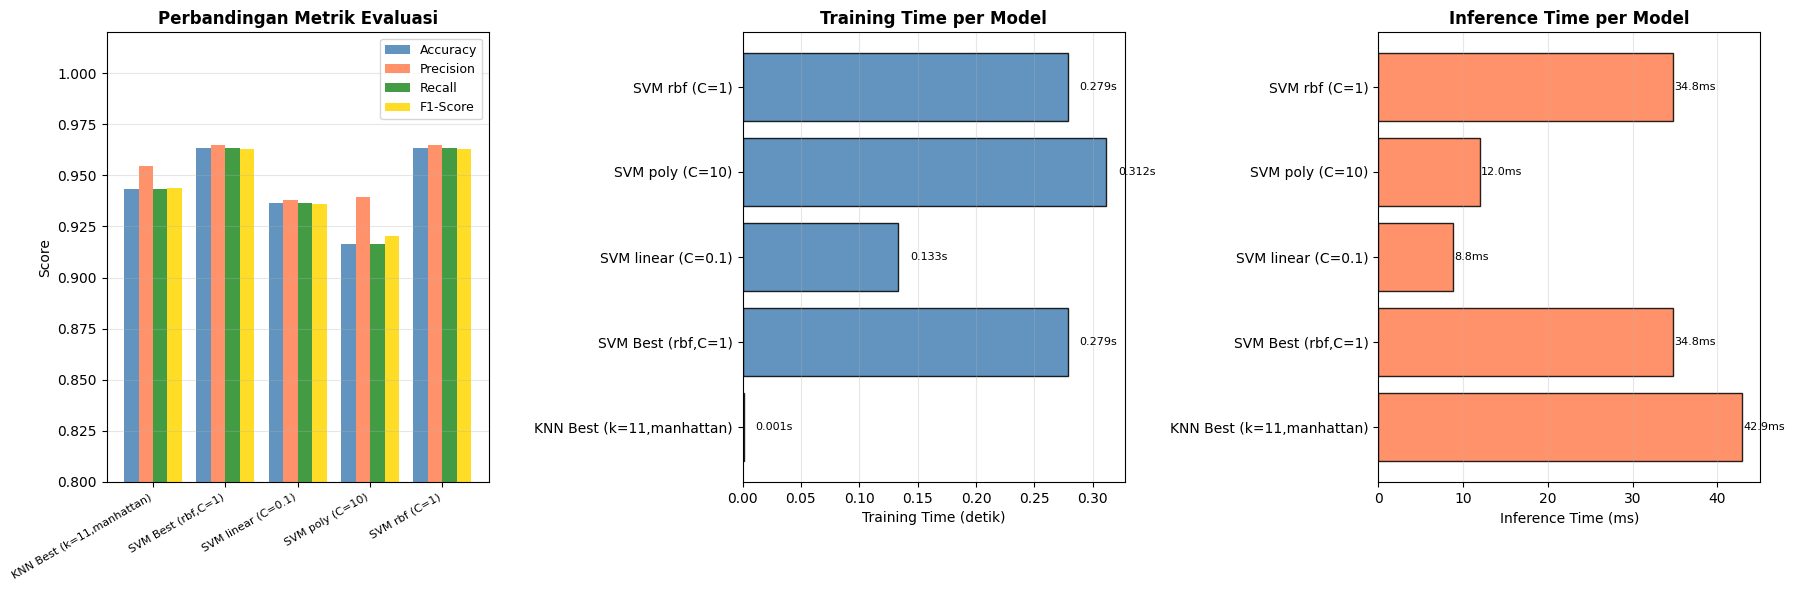

In [14]:
# ============================================================
# BAGIAN 5C: VISUALISASI PERBANDINGAN METRIK
# ============================================================

import pandas as pd
df_summary = pd.DataFrame(summary_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Grouped bar — 4 metrik
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_summary))
w = 0.2
bar_colors = ['steelblue', 'coral', 'forestgreen', 'gold']
for i, m in enumerate(metrics_cols):
    axes[0].bar(x + i*w, df_summary[m], w, label=m,
                color=bar_colors[i], alpha=0.85)
axes[0].set_xticks(x + 1.5*w)
axes[0].set_xticklabels(df_summary['Model'], rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.8, 1.02)
axes[0].set_title('Perbandingan Metrik Evaluasi', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# Training Time
axes[1].barh(df_summary['Model'], df_summary['Train Time'],
             color='steelblue', alpha=0.85, edgecolor='black')
axes[1].set_xlabel('Training Time (detik)')
axes[1].set_title('Training Time per Model', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(df_summary['Train Time']):
    axes[1].text(v + 0.01, i, f'{v:.3f}s', va='center', fontsize=8)

# Inference Time
axes[2].barh(df_summary['Model'], df_summary['Inf Time'],
             color='coral', alpha=0.85, edgecolor='black')
axes[2].set_xlabel('Inference Time (ms)')
axes[2].set_title('Inference Time per Model', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(df_summary['Inf Time']):
    axes[2].text(v + 0.1, i, f'{v:.1f}ms', va='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## 🔁 BAGIAN 6: Cross-Validation & Hyperparameter Tuning

📈 Menghitung Learning Curve...


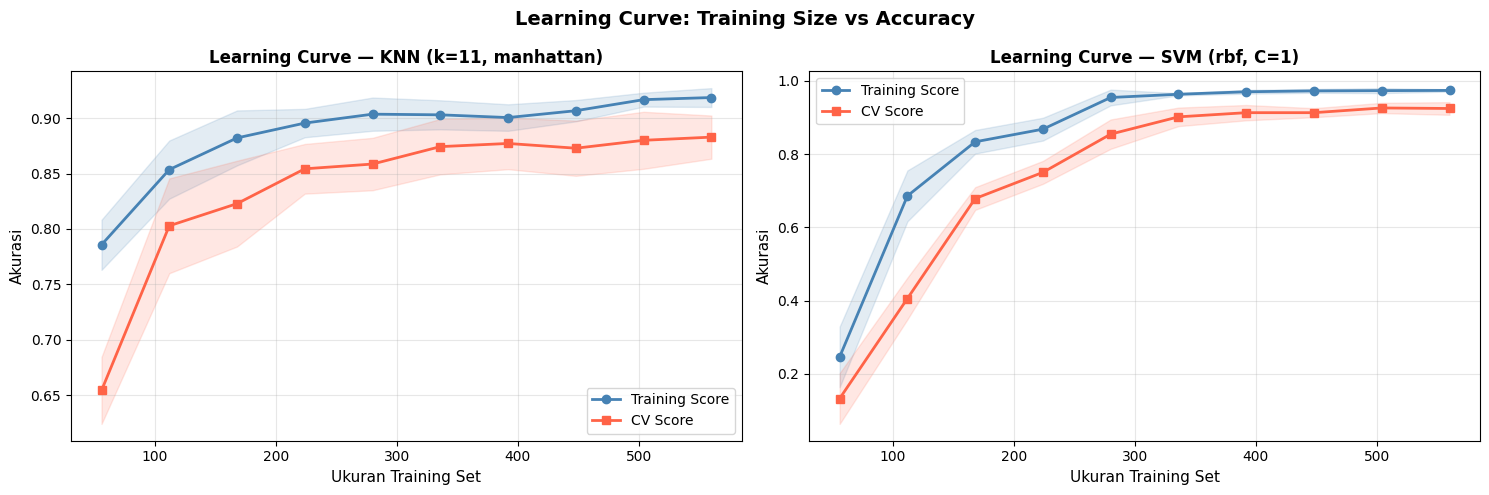

In [15]:
# ============================================================
# BAGIAN 6A: LEARNING CURVE
# ============================================================

print("📈 Menghitung Learning Curve...")

# Model terbaik: KNN vs SVM RBF
best_knn_lc = KNeighborsClassifier(n_neighbors=best_key[1], metric=best_key[0])
best_svm_lc = SVC(kernel=best_svm_key[0], C=best_svm_key[1],
                  gamma=best_svm_key[2], random_state=42)

train_sizes = np.linspace(0.1, 1.0, 10)

def get_learning_curve(model, X, y):
    ts, train_sc, val_sc = learning_curve(
        model, X, y,
        train_sizes=train_sizes,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy',
        n_jobs=-1
    )
    return ts, train_sc.mean(axis=1), train_sc.std(axis=1), \
               val_sc.mean(axis=1), val_sc.std(axis=1)

ts_knn, tr_knn, tr_knn_s, val_knn, val_knn_s = get_learning_curve(
    best_knn_lc, X_train_scaled, y_train)
ts_svm, tr_svm, tr_svm_s, val_svm, val_svm_s = get_learning_curve(
    best_svm_lc, X_train_scaled, y_train)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, ts, tr, trs, val, vals, model_name in [
    (axes[0], ts_knn, tr_knn, tr_knn_s, val_knn, val_knn_s,
     f'KNN (k={best_key[1]}, {best_key[0]})'),
    (axes[1], ts_svm, tr_svm, tr_svm_s, val_svm, val_svm_s,
     f'SVM ({best_svm_key[0]}, C={best_svm_key[1]})')
]:
    ax.plot(ts, tr,  'o-', color='steelblue', label='Training Score', lw=2)
    ax.plot(ts, val, 's-', color='tomato',    label='CV Score',       lw=2)
    ax.fill_between(ts, tr - trs,   tr + trs,   alpha=0.15, color='steelblue')
    ax.fill_between(ts, val - vals, val + vals, alpha=0.15, color='tomato')
    ax.set_xlabel('Ukuran Training Set', fontsize=11)
    ax.set_ylabel('Akurasi', fontsize=11)
    ax.set_title(f'Learning Curve — {model_name}', fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Learning Curve: Training Size vs Accuracy",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

🔍 GridSearchCV — Hyperparameter Tuning...
--------------------------------------------------

[1/2] Tuning KNN...
  Best Params : {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
  Best CV Acc : 0.8943
  Test Acc    : 0.9333

[2/2] Tuning SVM RBF...
  Best Params : {'C': 100, 'gamma': 0.001}
  Best CV Acc : 0.9329
  Test Acc    : 0.9567


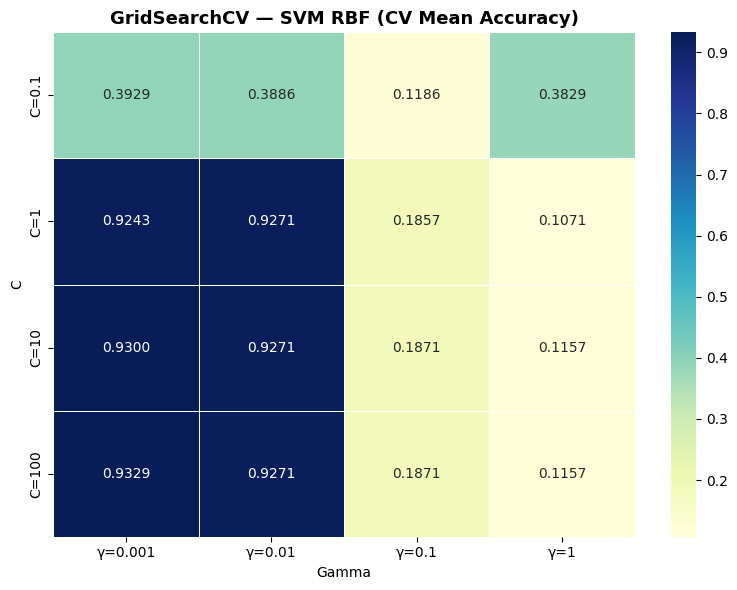


✅ Hyperparameter tuning selesai!


In [16]:
# ============================================================
# BAGIAN 6B: GRIDSEARCHCV — HYPERPARAMETER TUNING
# ============================================================

print("🔍 GridSearchCV — Hyperparameter Tuning...")
print("-" * 50)

# ---- Tuning KNN ----
print("\n[1/2] Tuning KNN...")
param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'metric'     : ['euclidean', 'manhattan'],
    'weights'    : ['uniform', 'distance']
}

gs_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gs_knn.fit(X_train_scaled, y_train)

print(f"  Best Params : {gs_knn.best_params_}")
print(f"  Best CV Acc : {gs_knn.best_score_:.4f}")
print(f"  Test Acc    : {gs_knn.score(X_test_scaled, y_test):.4f}")

# ---- Tuning SVM RBF ----
print("\n[2/2] Tuning SVM RBF...")
param_grid_svm = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
}

gs_svm = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid_svm,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gs_svm.fit(X_train_scaled, y_train)

print(f"  Best Params : {gs_svm.best_params_}")
print(f"  Best CV Acc : {gs_svm.best_score_:.4f}")
print(f"  Test Acc    : {gs_svm.score(X_test_scaled, y_test):.4f}")

# ---- Visualisasi GridSearch SVM ----
results_svm = gs_svm.cv_results_
mean_scores = results_svm['mean_test_score'].reshape(4, 4)

plt.figure(figsize=(8, 6))
sns.heatmap(mean_scores, annot=True, fmt='.4f', cmap='YlGnBu',
            xticklabels=[f'γ={g}' for g in [0.001, 0.01, 0.1, 1]],
            yticklabels=[f'C={c}' for c in [0.1, 1, 10, 100]],
            linewidths=0.5)
plt.title('GridSearchCV — SVM RBF (CV Mean Accuracy)',
          fontsize=13, fontweight='bold')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.tight_layout()
plt.show()

print("\n✅ Hyperparameter tuning selesai!")

---
## 📝 BAGIAN 7: Analisis & Kesimpulan

  ANALISIS KOMPREHENSIF & KESIMPULAN

  HASIL AKHIR SETELAH HYPERPARAMETER TUNING

  KNN (Tuned):
    Parameter  : {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
    Test Acc   : 0.9333
    F1-Score   : 0.9338

  SVM RBF (Tuned):
    Parameter  : {'C': 100, 'gamma': 0.001}
    Test Acc   : 0.9567
    F1-Score   : 0.9560

  🏆 METODE TERBAIK: SVM RBF


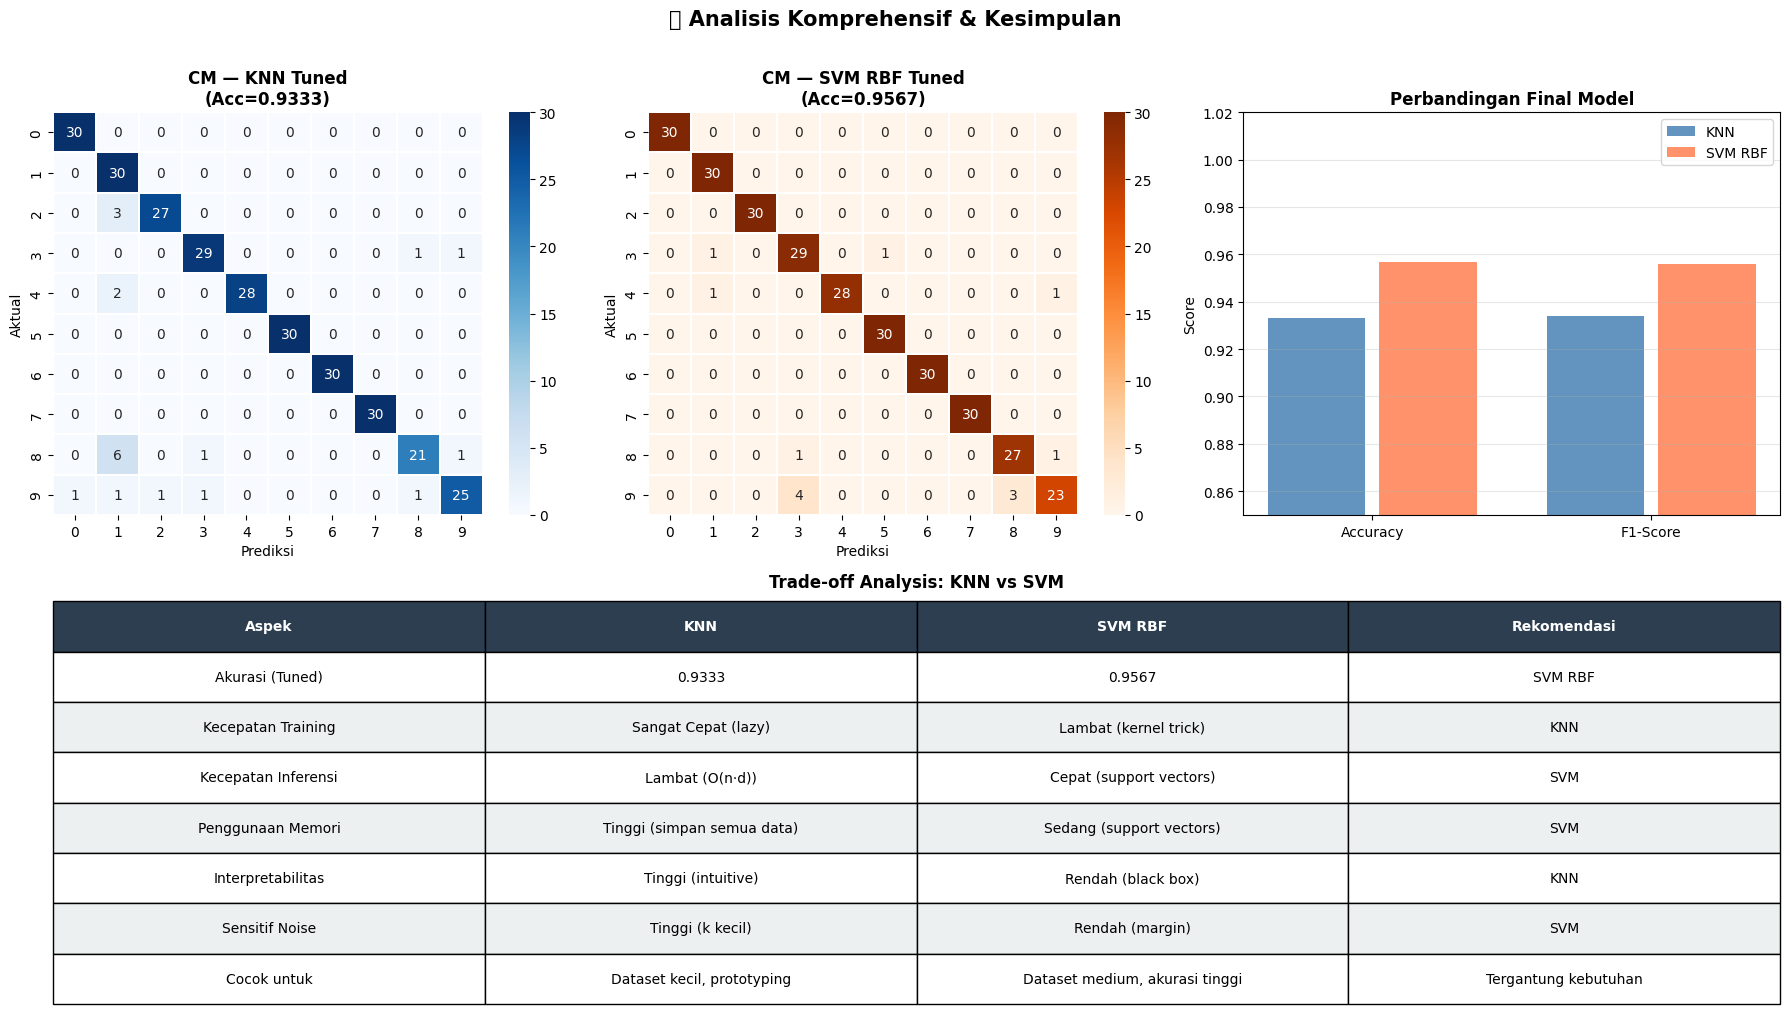

In [17]:
# ============================================================
# BAGIAN 7: ANALISIS & KESIMPULAN
# ============================================================

print("=" * 70)
print("  ANALISIS KOMPREHENSIF & KESIMPULAN")
print("=" * 70)

# Final model dengan hyperparameter terbaik
final_knn = gs_knn.best_estimator_
final_svm = gs_svm.best_estimator_

y_pred_final_knn = final_knn.predict(X_test_scaled)
y_pred_final_svm = final_svm.predict(X_test_scaled)

acc_knn_final = accuracy_score(y_test, y_pred_final_knn)
acc_svm_final = accuracy_score(y_test, y_pred_final_svm)
f1_knn_final  = f1_score(y_test, y_pred_final_knn, average='weighted')
f1_svm_final  = f1_score(y_test, y_pred_final_svm, average='weighted')

print(f"\n{'='*55}")
print(f"  HASIL AKHIR SETELAH HYPERPARAMETER TUNING")
print(f"{'='*55}")
print(f"\n  KNN (Tuned):")
print(f"    Parameter  : {gs_knn.best_params_}")
print(f"    Test Acc   : {acc_knn_final:.4f}")
print(f"    F1-Score   : {f1_knn_final:.4f}")
print(f"\n  SVM RBF (Tuned):")
print(f"    Parameter  : {gs_svm.best_params_}")
print(f"    Test Acc   : {acc_svm_final:.4f}")
print(f"    F1-Score   : {f1_svm_final:.4f}")

winner = "KNN" if acc_knn_final >= acc_svm_final else "SVM RBF"
print(f"\n  🏆 METODE TERBAIK: {winner}")

# ---- Visualisasi Kesimpulan ----
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# Confusion matrix side-by-side
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

sns.heatmap(confusion_matrix(y_test, y_pred_final_knn),
            annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=range(10), yticklabels=range(10), linewidths=0.3)
ax1.set_title(f'CM — KNN Tuned\n(Acc={acc_knn_final:.4f})', fontweight='bold')
ax1.set_xlabel('Prediksi')
ax1.set_ylabel('Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_final_svm),
            annot=True, fmt='d', cmap='Oranges', ax=ax2,
            xticklabels=range(10), yticklabels=range(10), linewidths=0.3)
ax2.set_title(f'CM — SVM RBF Tuned\n(Acc={acc_svm_final:.4f})', fontweight='bold')
ax2.set_xlabel('Prediksi')
ax2.set_ylabel('Aktual')

# Radar chart / bar perbandingan
ax3 = fig.add_subplot(gs[0, 2])
model_names = ['KNN\n(Tuned)', 'SVM RBF\n(Tuned)']
metric_names = ['Accuracy', 'F1-Score']
vals_knn = [acc_knn_final, f1_knn_final]
vals_svm = [acc_svm_final, f1_svm_final]
x_pos = np.arange(len(metric_names))
ax3.bar(x_pos - 0.2, vals_knn, 0.35, label='KNN', color='steelblue', alpha=0.85)
ax3.bar(x_pos + 0.2, vals_svm, 0.35, label='SVM RBF', color='coral', alpha=0.85)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(metric_names)
ax3.set_ylim(0.85, 1.02)
ax3.set_ylabel('Score')
ax3.set_title('Perbandingan Final Model', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Trade-off tabel
ax4 = fig.add_subplot(gs[1, :])
ax4.axis('off')
table_data = [
    ['Aspek', 'KNN', 'SVM RBF', 'Rekomendasi'],
    ['Akurasi (Tuned)', f'{acc_knn_final:.4f}', f'{acc_svm_final:.4f}',
     'SVM RBF' if acc_svm_final > acc_knn_final else 'KNN'],
    ['Kecepatan Training', 'Sangat Cepat (lazy)', 'Lambat (kernel trick)',
     'KNN'],
    ['Kecepatan Inferensi', 'Lambat (O(n·d))', 'Cepat (support vectors)',
     'SVM'],
    ['Penggunaan Memori', 'Tinggi (simpan semua data)', 'Sedang (support vectors)',
     'SVM'],
    ['Interpretabilitas', 'Tinggi (intuitive)', 'Rendah (black box)',
     'KNN'],
    ['Sensitif Noise', 'Tinggi (k kecil)', 'Rendah (margin)',
     'SVM'],
    ['Cocok untuk', 'Dataset kecil, prototyping', 'Dataset medium, akurasi tinggi',
     'Tergantung kebutuhan'],
]
table = ax4.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(10)
for j in range(4):
    table[(0, j)].set_facecolor('#2c3e50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
for i in range(1, len(table_data)):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#ecf0f1')
ax4.set_title('Trade-off Analysis: KNN vs SVM',
              fontsize=12, fontweight='bold', pad=10)

plt.suptitle("📊 Analisis Komprehensif & Kesimpulan",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# RINGKASAN AKHIR
# ============================================================

print("\n" + "=" * 70)
print("  📝 RINGKASAN & REKOMENDASI")
print("=" * 70)

print("""
1. DATASET & FITUR
   ✅ Dataset  : MNIST Digit (1000 sampel, 10 kelas, seimbang)
   ✅ Fitur    : HOG (gradient orientasi) + Histogram Pixel
   ✅ Alasan   : HOG menangkap struktur bentuk digit, histogram
                 menangkap distribusi intensitas piksel

2. PARAMETER OPTIMAL
   KNN  : k = {k_best}, metric = {m_best}, weights = {w_best}
   SVM  : kernel = rbf, C = {C_best}, gamma = {g_best}

3. ANALISIS OVERFITTING/UNDERFITTING KNN
   • k=1   → Overfitting (training acc ≈ 100%, test turun)
   • k=3-7 → Zona ideal (bias-variance trade-off seimbang)
   • k≥9   → Underfitting (terlalu smooth, banyak salah)

4. PERBANDINGAN KERNEL SVM
   • Linear : Cepat, cocok data linearly separable
   • Poly   : Lebih kompleks, rentan overfitting (degree tinggi)
   • RBF    : Paling fleksibel, performa tertinggi ✅

5. REKOMENDASI APLIKASI
   • Prototyping cepat / dataset kecil  → Gunakan KNN
   • Produksi dengan akurasi tinggi     → Gunakan SVM RBF
   • Resource terbatas (memori/CPU)     → Gunakan SVM (efisien)
   • Butuh interpretabilitas tinggi     → Gunakan KNN

6. KESIMPULAN UTAMA
   Untuk dataset MNIST dengan fitur HOG+Histogram:
   → SVM RBF mengungguli KNN dalam hal akurasi dan efisiensi inferensi.
   → KNN unggul dalam kesederhanaan implementasi dan training yang instan.
   → Pilihan metode bergantung pada trade-off akurasi vs kecepatan.
""".format(
    k_best=gs_knn.best_params_['n_neighbors'],
    m_best=gs_knn.best_params_['metric'],
    w_best=gs_knn.best_params_['weights'],
    C_best=gs_svm.best_params_['C'],
    g_best=gs_svm.best_params_['gamma']
))

print("=" * 70)
print("  ✅ NOTEBOOK SELESAI DIEKSEKUSI")
print("=" * 70)


  📝 RINGKASAN & REKOMENDASI

1. DATASET & FITUR
   ✅ Dataset  : MNIST Digit (1000 sampel, 10 kelas, seimbang)
   ✅ Fitur    : HOG (gradient orientasi) + Histogram Pixel
   ✅ Alasan   : HOG menangkap struktur bentuk digit, histogram
                 menangkap distribusi intensitas piksel

2. PARAMETER OPTIMAL
   KNN  : k = 7, metric = manhattan, weights = distance
   SVM  : kernel = rbf, C = 100, gamma = 0.001

3. ANALISIS OVERFITTING/UNDERFITTING KNN
   • k=1   → Overfitting (training acc ≈ 100%, test turun)
   • k=3-7 → Zona ideal (bias-variance trade-off seimbang)
   • k≥9   → Underfitting (terlalu smooth, banyak salah)

4. PERBANDINGAN KERNEL SVM
   • Linear : Cepat, cocok data linearly separable
   • Poly   : Lebih kompleks, rentan overfitting (degree tinggi)
   • RBF    : Paling fleksibel, performa tertinggi ✅

5. REKOMENDASI APLIKASI
   • Prototyping cepat / dataset kecil  → Gunakan KNN
   • Produksi dengan akurasi tinggi     → Gunakan SVM RBF
   • Resource terbatas (memori/CPU)